In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import glob

In [2]:
files = glob.glob("data/litellm/public.LiteLLM_SpendLogs/1/*.parquet")  # adjust path
 
df_base = pd.DataFrame()

for file in files:
    new_df = pd.read_parquet(file).drop(inplace=False,columns=["model_id","metadata", "cache_hit","cache_key",'api_key',"call_type", 'team_id', 'requester_ip_address', 'messages', 'response', 'proxy_server_request', 'session_id',"mcp_namespaced_tool_name"])
    df_base = pd.concat([df_base,pd.read_parquet(file)])

    

len(df_base)

713244

In [7]:

for name in df_base["model"].unique():
    print(name, end=": ")
    print(df_base[df_base["model"] == name]["model"].count())

eu.meta.llama3-2-3b-instruct-v1:0: 224943
apertus-8b: 138
swiss-ai/apertus-8b-instruct: 7035
openai/gpt-oss-120b: 304
aisingapore/Gemma-SEA-LION-v3-9B-IT: 1849
meta-llama/Llama-3.2-3B-Instruct: 5427
swiss-ai/apertus-8b-it: 62
apertus-70b: 155
cohere.embed-multilingual-v3: 83001
gemma-sea-lion-v3-9b-it: 2
llama3-2-3b-instruct: 14
: 116
gpt-oss-120b: 23
apertus-8b-instruct: 117002
/models/Apertus-8B-aligned-branded: 79
apertus-70b-instruct: 103888
/models/Apertus-70B-aligned-branded: 14
swiss-ai/apertus-70b-it: 9
Cohere/Cohere-embed-multilingual-v3.0: 21259
swiss-ai/apertus-70b-instruct: 8842
gpt-3.5-turbo: 5
publicai-base-v1: 2
qwen3:30b-a3b: 1
model: 9
Apertus-70B-Instruct-2509: 2
apertus-70b-instruct-2509: 5
Apertus-70b-2509: 1
apertus-70b-instruct-2507: 1
swissai/apertus-70b-instruct: 3
apertus-8b-it: 1
gpt-4.1-nano: 1
Apertus: 9
apertus-80b-instruct: 1
swiss-ai/apertus-8b-instruct-exoscale: 2023
swiss-ai/Apertus-8B-Instruct-2509: 100899
mistral-small-2402: 1
swissai/apertus-8b-instr

In [6]:
df_base["date"] = df_base["startTime"].apply(lambda x: x.split(" ")[0])

df_base["date"].nunique()

33

In [8]:
df_base.head(3)

,request_id,call_type,api_key,spend,total_tokens,prompt_tokens,completion_tokens,startTime,endTime,completionStartTime,...,request_tags,team_id,end_user,requester_ip_address,messages,response,proxy_server_request,session_id,status,mcp_namespaced_tool_name
0,chatcmpl-07b28b64-5158-4c65-8897-769b5ddf4cbb,acompletion,None,0.000062,327,291,36,2025-08-30 03:59:21.616,2025-08-30 03:59:23.435,2025-08-30 03:59:23.434,...,"[""User-Agent: Python"", ""User-Agent: Python/3.1...",,enduser_d41d8cd9,None,None,None,None,d67ab01f-d871-45b3-8a11-44faef043f47,success,None
1,chatcmpl-18887802-83a5-4291-95ca-ddec5d092742,acompletion,None,0.000071,372,361,11,2025-08-30 03:59:23.547,2025-08-30 03:59:23.879,2025-08-30 03:59:23.879,...,"[""User-Agent: Python"", ""User-Agent: Python/3.1...",,enduser_d41d8cd9,None,None,None,None,fb112d1a-a8a9-4c4c-933a-3ce2df135205,success,None
2,chatcmpl-a6517e27-6f25-48a0-9f2a-309b9cdb33ea,acompletion,None,0.000060,315,246,69,2025-08-30 03:59:24.048,2025-08-30 03:59:25.196,2025-08-30 03:59:25.195,...,"[""User-Agent: Python"", ""User-Agent: Python/3.1...",,enduser_d41d8cd9,None,None,None,None,4f05525f-da77-4a99-9ada-5e2568caf110,success,None


In [15]:
map = { date:i+1 for i, date in enumerate(np.sort(df_base["date"].unique()))}


df_base["day"] = df_base["date"].apply(lambda x: map[x])





In [18]:
df_base.columns

Index(['request_id', 'call_type', 'api_key', 'spend', 'total_tokens',
       'prompt_tokens', 'completion_tokens', 'startTime', 'endTime',
       'completionStartTime', 'model', 'model_id', 'model_group',
       'custom_llm_provider', 'api_base', 'user', 'metadata', 'cache_hit',
       'cache_key', 'request_tags', 'team_id', 'end_user',
       'requester_ip_address', 'messages', 'response', 'proxy_server_request',
       'session_id', 'status', 'mcp_namespaced_tool_name', 'date', 'day'],
      dtype='object')

In [ ]:
df_user = df_base[["end_user","day","total_tokens","prompt_tokens","completion_tokens"]].groupby(["end_user","day"]).sum().reset_index()


,end_user,day,total_tokens,prompt_tokens,completion_tokens
0,enduser_000014fc,5,3496,2645,851
1,enduser_00010461,16,23963,18197,5766
2,enduser_000161ee,5,19486,15270,4216
3,enduser_00033358,12,4744,4022,722
4,enduser_0007e4bd,5,27267,22728,4539


In [84]:
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler


X_scaled = StandardScaler().fit_transform(df_user_p)

pca =TruncatedSVD(n_components=3,random_state=42)
X_spca = pca.fit_transform(X_scaled)

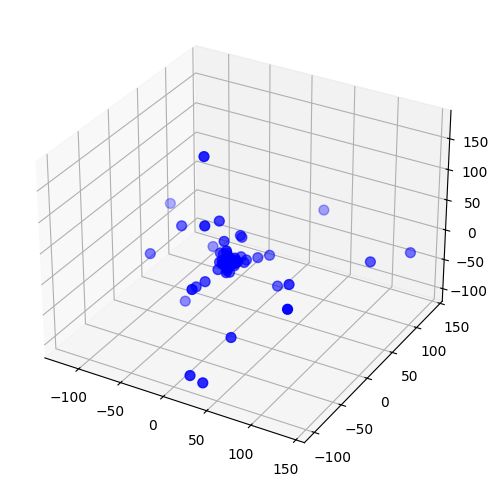

In [85]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_spca[:,0], X_spca[:,1], X_spca[:,2], c='blue', s=50)

In [99]:
df_base[df_base["end_user"] == "enduser_000014fc"]

,request_id,call_type,api_key,spend,total_tokens,prompt_tokens,completion_tokens,startTime,endTime,completionStartTime,...,end_user,requester_ip_address,messages,response,proxy_server_request,session_id,status,mcp_namespaced_tool_name,date,day
5877,chatcmpl-ed173ce4a24b4d0fb57eabcedb2cd37d,acompletion,None,0.000000,693,136,557,2025-09-03 12:05:35.074,2025-09-03 12:05:51.418,2025-09-03 12:05:35.254,...,enduser_000014fc,None,None,None,None,aeb5c437-c7bc-4861-b3c1-99d5d265f9b9,success,None,2025-09-03,5
5902,chatcmpl-ba6e9c80-ee46-4c98-b046-d05588d99fa1,acompletion,None,0.000178,936,828,108,2025-09-03 12:05:51.525,2025-09-03 12:05:53.173,2025-09-03 12:05:53.172,...,enduser_000014fc,None,None,None,None,1a16140d-060a-4fac-b029-cd874757c903,success,None,2025-09-03,5
5905,chatcmpl-8fd62584-a488-437c-b9ae-d60f78e1ce60,acompletion,None,0.000181,954,783,171,2025-09-03 12:05:53.735,2025-09-03 12:05:56.127,2025-09-03 12:05:56.126,...,enduser_000014fc,None,None,None,None,21791a29-dfc6-453a-b58e-a5d71bf0bf13,success,None,2025-09-03,5
5923,chatcmpl-fe20b39e-dcb0-4671-aa2e-1fba7a1c206a,acompletion,None,0.000173,913,898,15,2025-09-03 12:05:53.277,2025-09-03 12:05:53.659,2025-09-03 12:05:53.658,...,enduser_000014fc,None,None,None,None,95e67ebf-4849-4d09-ac1c-ad2574f5bf49,success,None,2025-09-03,5


### AutoEncoders

In [103]:
all_users = df_user["end_user"].unique()
all_days = df_user["day"].unique()

full_index = pd.MultiIndex.from_product([all_users,all_days],names = ["end_user","day"])

df_user_padded = df_user.set_index(["end_user","day"]).reindex(full_index,fill_value=0).reset_index().sort_values(by = ["end_user","day"])



df_user_embed = df_user_padded.groupby("end_user")[["total_tokens","prompt_tokens","completion_tokens"]].apply(lambda x: x.values.tolist()).reset_index()

df_user_embed.head()

,end_user,0
0,enduser_000014fc,"[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], [..."
1,enduser_00010461,"[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], [..."
2,enduser_000161ee,"[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], [..."
3,enduser_00033358,"[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], [..."
4,enduser_0007e4bd,"[[0, 0, 0], [0, 0, 0], [0, 0, 0], [0, 0, 0], [..."


In [136]:
len(df_user_embed)

21267

In [119]:
X = np.stack(np.array(df_user_embed[0]))

In [124]:
import torch
import torch.nn as nn

In [141]:
from torch.utils.data import DataLoader, TensorDataset
class SeqAutoEncoder(nn.Module):

    def __init__(self, input_dim = 3,hidden_dim = 64,embedding_dim = 8, num_layers = 2,dropout = 0.2):
        super().__init__()

        self.encoder = nn.LSTM(input_dim,hidden_dim,num_layers=num_layers,batch_first=True,dropout=dropout)
        self.fc_enc = nn.Linear(hidden_dim,embedding_dim)
        self.activation1 = nn.LeakyReLU(negative_slope=0.05)
        self.fc_dec = nn.Linear(embedding_dim,hidden_dim)
        self.decoder = nn.LSTM(input_dim,hidden_dim, num_layers=num_layers,batch_first=True,dropout=dropout)
        self.fc_map = nn.Linear(hidden_dim,input_dim)
        self.activation3 = nn.ReLU()
    
    def forward(self,X):
     
        batch_size,seq_len, _ =X.shape

        _, (h_n, c_n) = self.encoder(X)
        embedding = self.fc_enc(h_n[-1])
        embedding = self.activation1(embedding)
        h_dec = self.fc_dec(embedding).unsqueeze(0).repeat(self.decoder.num_layers,1,1)
        input_dec = torch.zeros(batch_size, seq_len, X.size(2), device=X.device)
        dec_out, _ = self.decoder(input_dec, (h_dec, torch.zeros_like(h_dec)))
        dec_out = self.fc_map(dec_out)
        dec_out = self.activation3(dec_out)

   
        return dec_out, embedding
    




X_tensor = torch.log1p(torch.tensor(X,dtype=torch.float32))
dataset = TensorDataset(X_tensor)
dataloader = DataLoader(dataset,batch_size = 32,shuffle=True)


device = torch.device("cpu")

model = SeqAutoEncoder().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, betas=(0.9, 0.999))
criterion = nn.MSELoss()


num_epochs = 100
for epoch in range(num_epochs):
    total_loss = 0
    for batch in dataloader:
        x_batch = batch[0].to(device)

        optimizer.zero_grad()
        x_rec, embed = model(x_batch)
        loss = criterion(x_rec,x_batch)
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch}: Loss - {total_loss/len(dataloader):.4f}")




Epoch 0: Loss - 3.7964
Epoch 1: Loss - 3.7958
Epoch 2: Loss - 3.7962
Epoch 3: Loss - 3.7957
Epoch 4: Loss - 3.7957
Epoch 5: Loss - 3.7969
Epoch 6: Loss - 3.7964
Epoch 7: Loss - 3.7966
Epoch 8: Loss - 3.7964
Epoch 9: Loss - 3.7965
Epoch 10: Loss - 3.7959
Epoch 11: Loss - 3.7962
Epoch 12: Loss - 3.7959
Epoch 13: Loss - 3.7963
Epoch 14: Loss - 3.7965
Epoch 15: Loss - 3.7959
Epoch 16: Loss - 3.7964
Epoch 17: Loss - 3.7961
Epoch 18: Loss - 3.7958
Epoch 19: Loss - 3.7965
Epoch 20: Loss - 3.7959
Epoch 21: Loss - 3.7961
Epoch 22: Loss - 3.7962


KeyboardInterrupt: 